# Продуктовая аналитика воронки и удержания для e-commerce

Цель ноутбука — оценить путь пользователя от просмотра товара до покупки, найти различия между категориями и брендами, проверить удержание покупательских когорт и выделить пользовательские сегменты для продуктовых рекомендаций.

## 1. Постановка бизнес-вопроса

Основной бизнес-вопрос: как пользователи проходят путь `view -> cart -> purchase`, где возникают потери воронки, какие категории и бренды дают лучший вклад в покупки и какие сегменты пользователей требуют разных продуктовых действий.

## 2. Описание данных

Анализ строится на событийных данных интернет-магазина косметики. Входной слой уже подготовлен ETL-процессом, а SQL-витрины собраны в DuckDB.

Если файл `data/marts/ecommerce.duckdb` отсутствует, сначала нужно выполнить:

```powershell
python scripts/run_etl.py
python scripts/build_marts.py
```

In [1]:
from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ecommerce_analytics.metrics import (
    calculate_abandoned_cart_share,
    calculate_funnel_metrics,
    calculate_repeat_purchase_rate,
)

DB_PATH = PROJECT_ROOT / "data" / "marts" / "ecommerce.duckdb"
HAS_MARTS = DB_PATH.exists()

if HAS_MARTS:
    con = duckdb.connect(str(DB_PATH), read_only=True)
else:
    con = None
    display(Markdown("**Данные не найдены.** Сначала запустите `python scripts/run_etl.py`, затем `python scripts/build_marts.py`."))

## 3. Период данных и объем событий

На этом шаге проверяем границы периода, количество событий, пользователей и сессий. Эти значения нужны как базовый контроль полноты данных перед интерпретацией метрик.

In [3]:
if HAS_MARTS:
    overview = con.execute(
        """
        SELECT
            MIN(event_date) AS period_start,
            MAX(event_date) AS period_end,
            COUNT(*) AS events_cnt,
            COUNT(DISTINCT user_id) AS users_cnt,
            COUNT(DISTINCT user_session) AS source_sessions_cnt
        FROM fct_events
        """
    ).fetchdf()
    sessions_cnt = con.execute("SELECT COUNT(*) AS sessions_cnt FROM fct_sessions").fetchdf()
    display(pd.concat([overview, sessions_cnt], axis=1).T.rename(columns={0: "Значение"}))

,Значение
period_start,2019-10-01 00:00:00
period_end,2020-02-29 00:00:00
events_cnt,19583618
users_cnt,1639358
source_sessions_cnt,4535940
sessions_cnt,4537808


## 4. KPI overview

В этом блоке считаются ключевые метрики: конверсия просмотра в покупку, конверсия корзины в покупку, доля повторных покупателей, GMV и доля брошенных корзин.

In [4]:
if HAS_MARTS:
    event_totals = con.execute(
        """
        SELECT
            SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS views_cnt,
            SUM(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS carts_cnt,
            SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchases_cnt,
            SUM(CASE WHEN event_type = 'purchase' THEN price ELSE 0 END) AS gmv
        FROM fct_events
        """
    ).fetchdf().iloc[0]

    purchases_by_user = con.execute(
        """
        SELECT user_id, COUNT(*) AS purchases_cnt
        FROM fct_events
        WHERE event_type = 'purchase'
        GROUP BY user_id
        """
    ).fetchdf()
    sessions = con.execute("SELECT session_id, carts_cnt, purchases_cnt FROM fct_sessions").fetchdf()

    funnel_metrics = calculate_funnel_metrics(
        int(event_totals["views_cnt"]),
        int(event_totals["carts_cnt"]),
        int(event_totals["purchases_cnt"]),
    )
    repeat_purchase_rate = calculate_repeat_purchase_rate(purchases_by_user)
    abandoned_cart_share = calculate_abandoned_cart_share(sessions)

    kpi = pd.DataFrame(
        [
            ["Конверсия просмотра в покупку", funnel_metrics["purchase_conversion_rate"]],
            ["Конверсия корзины в покупку", funnel_metrics["cart_to_purchase_rate"]],
            ["Доля повторных покупателей", repeat_purchase_rate],
            ["GMV", float(event_totals["gmv"] or 0)],
            ["Доля брошенных корзин", abandoned_cart_share],
        ],
        columns=["Метрика", "Значение"],
    )
    kpi_display = kpi.copy()
    kpi_display["Значение"] = kpi_display.apply(
        lambda row: f"{row['Значение']:,.2f}" if row["Метрика"] == "GMV" else f"{row['Значение']:.2%}",
        axis=1,
    )
    display(kpi_display)

,Метрика,Значение
0,Конверсия просмотра в покупку,13.32%
1,Конверсия корзины в покупку,22.75%
2,Доля повторных покупателей,89.65%
3,GMV,"6,348,267.70"
4,Доля брошенных корзин,87.21%


## 5. Funnel analysis

Смотрим общую воронку `view -> cart -> purchase`, затем сравниваем категории и бренды по конверсии в покупку.

,Этап,События
0,Просмотр,9656788.0
1,Корзина,5652991.0
2,Покупка,1285983.0


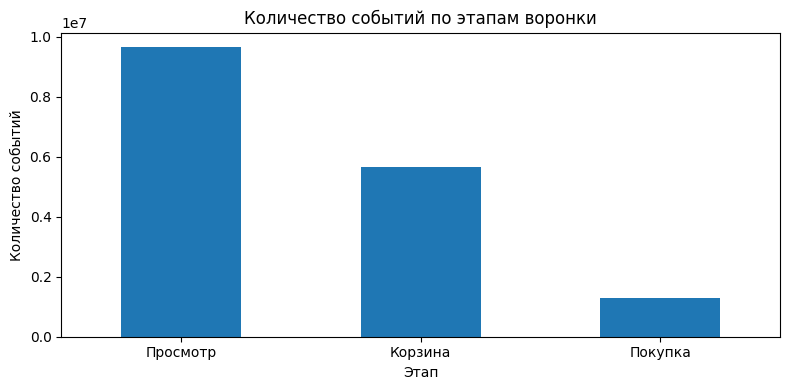

In [12]:
if HAS_MARTS:
    funnel = pd.DataFrame(
        {
            "Этап": ["Просмотр", "Корзина", "Покупка"],
            "События": [event_totals["views_cnt"], event_totals["carts_cnt"], event_totals["purchases_cnt"]],
        }
    )
    display(funnel)

    ax = funnel.plot(kind="bar", x="Этап", y="События", legend=False, figsize=(8, 4))
    ax.set_title("Количество событий по этапам воронки")
    ax.set_xlabel("Этап")
    ax.set_ylabel("Количество событий")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

,category_code,views_cnt,carts_cnt,purchases_cnt,revenue,purchase_conversion_rate
0,Без категории,9427126.0,5586576.0,1268827.0,6087978.92,0.134593
1,appliances.environment.vacuum,113737.0,18700.0,4000.0,138623.97,0.035169
2,furniture.living_room.cabinet,26240.0,2247.0,293.0,40746.98,0.011166
3,accessories.bag,22571.0,907.0,182.0,7833.37,0.008063
4,apparel.glove,20731.0,15942.0,4977.0,34340.60,0.240075
5,stationery.cartrige,20582.0,22441.0,6270.0,13978.99,0.304635
6,furniture.bathroom.bath,15086.0,4670.0,1161.0,18706.83,0.076959
7,appliances.personal.hair_cutter,4660.0,435.0,58.0,2437.83,0.012446
8,appliances.personal.massager,2822.0,258.0,44.0,2012.05,0.015592
9,accessories.cosmetic_bag,2506.0,619.0,132.0,938.40,0.052674


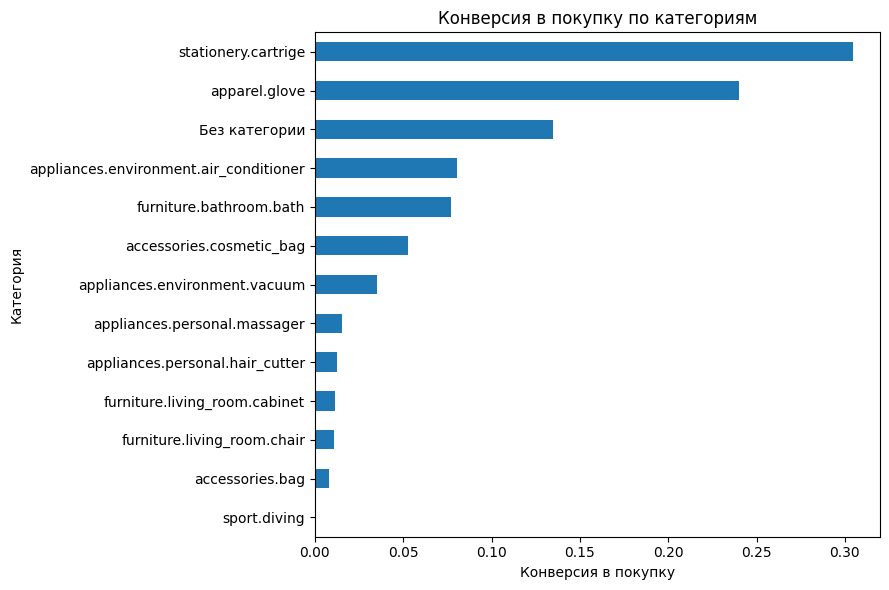

In [6]:
if HAS_MARTS:
    category_funnel = con.execute(
        """
        SELECT
            COALESCE(category_code, 'Без категории') AS category_code,
            SUM(views_cnt) AS views_cnt,
            SUM(carts_cnt) AS carts_cnt,
            SUM(purchases_cnt) AS purchases_cnt,
            SUM(revenue) AS revenue,
            SUM(purchases_cnt)::DOUBLE / NULLIF(SUM(views_cnt), 0) AS purchase_conversion_rate
        FROM mart_funnel_daily
        GROUP BY category_code
        HAVING SUM(views_cnt) > 0
        ORDER BY views_cnt DESC
        LIMIT 15
        """
    ).fetchdf()
    display(category_funnel)

    ax = category_funnel.sort_values("purchase_conversion_rate").plot(
        kind="barh",
        x="category_code",
        y="purchase_conversion_rate",
        legend=False,
        figsize=(9, 6),
    )
    ax.set_title("Конверсия в покупку по категориям")
    ax.set_xlabel("Конверсия в покупку")
    ax.set_ylabel("Категория")
    plt.tight_layout()
    plt.show()

,brand,views_cnt,carts_cnt,purchases_cnt,revenue,purchase_conversion_rate
0,Без бренда,3972059.0,2439110.0,549313.0,2563155.51,0.138294
1,runail,608798.0,475816.0,111350.0,343306.15,0.182901
2,grattol,426211.0,216196.0,49542.0,266295.94,0.116238
3,irisk,409692.0,324270.0,73747.0,223771.21,0.180006
4,masura,342216.0,245772.0,49566.0,138568.45,0.144838
5,estel,206016.0,85219.0,19424.0,121714.03,0.094284
6,kapous,196888.0,71046.0,16281.0,62663.34,0.082692
7,ingarden,175622.0,123685.0,27401.0,124570.00,0.156023
8,jessnail,172218.0,42308.0,9661.0,134775.04,0.056098
9,bpw.style,168642.0,132258.0,37941.0,44634.70,0.224980


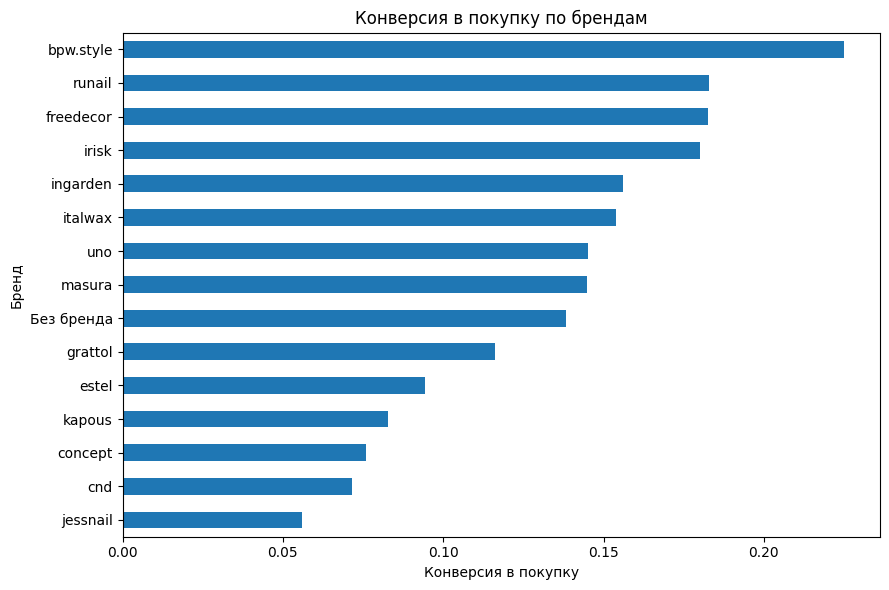

In [7]:
if HAS_MARTS:
    brand_funnel = con.execute(
        """
        SELECT
            COALESCE(brand, 'Без бренда') AS brand,
            SUM(views_cnt) AS views_cnt,
            SUM(carts_cnt) AS carts_cnt,
            SUM(purchases_cnt) AS purchases_cnt,
            SUM(revenue) AS revenue,
            SUM(purchases_cnt)::DOUBLE / NULLIF(SUM(views_cnt), 0) AS purchase_conversion_rate
        FROM mart_funnel_daily
        GROUP BY brand
        HAVING SUM(views_cnt) > 0
        ORDER BY views_cnt DESC
        LIMIT 15
        """
    ).fetchdf()
    display(brand_funnel)

    ax = brand_funnel.sort_values("purchase_conversion_rate").plot(
        kind="barh",
        x="brand",
        y="purchase_conversion_rate",
        legend=False,
        figsize=(9, 6),
    )
    ax.set_title("Конверсия в покупку по брендам")
    ax.set_xlabel("Конверсия в покупку")
    ax.set_ylabel("Бренд")
    plt.tight_layout()
    plt.show()

## 6. Когортное удержание

Когорты строятся по месяцу первой покупки. Удержание показывает, какая доля пользователей из когорты снова совершала покупки в следующие месяцы.

,cohort_month,order_month,months_since_first_purchase,active_users,cohort_size,retention_rate
0,2019-10-01,2019-10-01,0,25762,25762,1.000000
1,2019-10-01,2019-11-01,1,4763,25762,0.184885
2,2019-10-01,2019-12-01,2,3293,25762,0.127824
3,2019-10-01,2020-01-01,3,3399,25762,0.131939
4,2019-10-01,2020-02-01,4,2692,25762,0.104495
5,2019-11-01,2019-11-01,0,26761,26761,1.000000
6,2019-11-01,2019-12-01,1,2618,26761,0.097829
7,2019-11-01,2020-01-01,2,2716,26761,0.101491
8,2019-11-01,2020-02-01,3,2119,26761,0.079182
9,2019-12-01,2019-12-01,0,19702,19702,1.000000


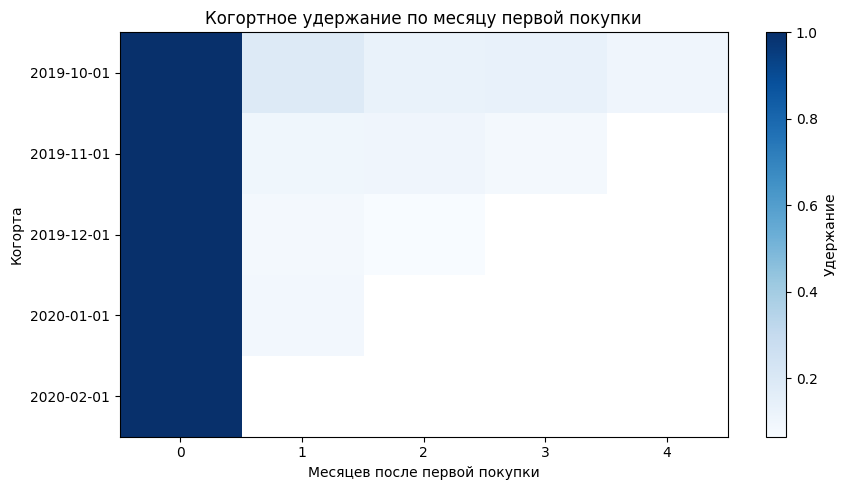

In [13]:
if HAS_MARTS:
    retention = con.execute(
        """
        SELECT
            cohort_month,
            order_month,
            months_since_first_purchase,
            active_users,
            cohort_size,
            retention_rate
        FROM mart_retention
        ORDER BY cohort_month, months_since_first_purchase
        """
    ).fetchdf()
    display(retention)

    retention_pivot = retention.pivot(
        index="cohort_month",
        columns="months_since_first_purchase",
        values="retention_rate",
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    image = ax.imshow(retention_pivot, aspect="auto", cmap="Blues")
    ax.set_title("Когортное удержание по месяцу первой покупки")
    ax.set_xlabel("Месяцев после первой покупки")
    ax.set_ylabel("Когорта")
    ax.set_xticks(range(len(retention_pivot.columns)))
    ax.set_xticklabels(retention_pivot.columns)
    ax.set_yticks(range(len(retention_pivot.index)))
    ax.set_yticklabels([str(value)[:10] for value in retention_pivot.index])
    fig.colorbar(image, ax=ax, label="Удержание")
    plt.tight_layout()
    plt.show()

## 7. Сегментация

Сегментация нужна, чтобы разделить пользователей по роли в продуктовой воронке: новые и возвращающиеся пользователи, активные смотрящие без покупок, покупатели и группы по ценности.

In [9]:
if HAS_MARTS:
    monthly_user_status = con.execute(
        """
        WITH user_months AS (
            SELECT DISTINCT
                user_id,
                DATE_TRUNC('month', event_time)::DATE AS activity_month
            FROM fct_events
        ),
        first_months AS (
            SELECT user_id, MIN(activity_month) AS first_activity_month
            FROM user_months
            GROUP BY user_id
        )
        SELECT
            user_months.activity_month,
            CASE
                WHEN user_months.activity_month = first_months.first_activity_month THEN 'Новые'
                ELSE 'Возвращающиеся'
            END AS user_segment,
            COUNT(DISTINCT user_months.user_id) AS users_cnt
        FROM user_months
        INNER JOIN first_months
            ON user_months.user_id = first_months.user_id
        GROUP BY user_months.activity_month, user_segment
        ORDER BY user_months.activity_month, user_segment
        """
    ).fetchdf()
    display(monthly_user_status)

    user_summary = con.execute(
        """
        SELECT
            user_id,
            SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS views_cnt,
            SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchases_cnt,
            SUM(CASE WHEN event_type = 'purchase' THEN price ELSE 0 END) AS revenue
        FROM fct_events
        GROUP BY user_id
        """
    ).fetchdf()
    views_threshold = user_summary["views_cnt"].quantile(0.75)
    user_summary["behavior_segment"] = "Прочие пользователи"
    user_summary.loc[user_summary["purchases_cnt"] > 0, "behavior_segment"] = "Покупатели"
    user_summary.loc[
        (user_summary["views_cnt"] >= views_threshold) & (user_summary["purchases_cnt"] == 0),
        "behavior_segment",
    ] = "Активно смотрят без покупки"
    display(user_summary.groupby("behavior_segment", as_index=False).agg(users_cnt=("user_id", "nunique")))

,activity_month,user_segment,users_cnt
0,2019-10-01,Новые,399664
1,2019-11-01,Возвращающиеся,54796
2,2019-11-01,Новые,313436
3,2019-12-01,Возвращающиеся,70693
4,2019-12-01,Новые,299461
5,2020-01-01,Возвращающиеся,81135
6,2020-01-01,Новые,328938
7,2020-02-01,Возвращающиеся,93196
8,2020-02-01,Новые,297859


,behavior_segment,users_cnt
0,Активно смотрят без покупки,404552
1,Покупатели,110518
2,Прочие пользователи,1124288


In [10]:
if HAS_MARTS:
    buyers = user_summary[user_summary["revenue"] > 0].copy()
    if buyers.empty:
        display(Markdown("Покупатели не найдены, сегменты по ценности не рассчитаны."))
    else:
        if buyers["revenue"].nunique() < 3:
            buyers["value_segment"] = "Средняя ценность"
        else:
            buyers["value_segment"] = pd.qcut(
                buyers["revenue"],
                q=3,
                labels=["Низкая ценность", "Средняя ценность", "Высокая ценность"],
                duplicates="drop",
            )
        value_segments = buyers.groupby("value_segment", observed=True).agg(
            users_cnt=("user_id", "nunique"),
            revenue=("revenue", "sum"),
            avg_revenue_per_user=("revenue", "mean"),
        ).reset_index()
        display(value_segments)

,value_segment,users_cnt,revenue,avg_revenue_per_user
0,Низкая ценность,36840,474331.22,12.875440
1,Средняя ценность,36841,1236256.54,33.556541
2,Высокая ценность,36837,4637679.94,125.897330


## 8. Продуктовые выводы

Выводы ниже должны строиться только на рассчитанных значениях. Если витрины не собраны, используйте шаблоны значений: `[X]%`, `[Y] п.п.`, `[Z] рублей`.

In [11]:
if HAS_MARTS:
    top_category = category_funnel.sort_values("purchase_conversion_rate", ascending=False).iloc[0]
    top_brand = brand_funnel.sort_values("purchase_conversion_rate", ascending=False).iloc[0]
    first_retention = retention[retention["months_since_first_purchase"] == 1]
    avg_month_1_retention = first_retention["retention_rate"].mean() if not first_retention.empty else 0
    buyer_segment_size = int(
        user_summary[user_summary["behavior_segment"] == "Покупатели"]["user_id"].nunique()
    )

    conclusions = [
        f"1. Общая конверсия просмотра в покупку составляет {funnel_metrics['purchase_conversion_rate']:.2%}; это базовая точка для оценки роста воронки.",
        f"2. Доля брошенных корзин составляет {abandoned_cart_share:.2%}; этот этап требует отдельного анализа причин потери пользователей.",
        f"3. Среди крупных категорий лучшая конверсия в покупку у `{top_category['category_code']}`: {top_category['purchase_conversion_rate']:.2%}.",
        f"4. Среди крупных брендов лучшая конверсия в покупку у `{top_brand['brand']}`: {top_brand['purchase_conversion_rate']:.2%}.",
        f"5. Среднее удержание первого месяца после первой покупки составляет {avg_month_1_retention:.2%}; число пользователей с покупками в периоде: {buyer_segment_size:,}.",
    ]
    display(Markdown("\n".join(conclusions)))

1. Общая конверсия просмотра в покупку составляет 13.32%; это базовая точка для оценки роста воронки.
2. Доля брошенных корзин составляет 87.21%; этот этап требует отдельного анализа причин потери пользователей.
3. Среди крупных категорий лучшая конверсия в покупку у `stationery.cartrige`: 30.46%.
4. Среди крупных брендов лучшая конверсия в покупку у `bpw.style`: 22.50%.
5. Среднее удержание первого месяца после первой покупки составляет 11.41%; число пользователей с покупками в периоде: 110,518.

## 9. Ограничения анализа

- Анализ зависит от полноты исходных CSV-файлов в `data/raw/`.
- Сессии с пустым `user_session` восстановлены по правилу разрыва больше 30 минут, поэтому они являются аналитической оценкой.
- Конверсии считаются по событиям, а не по строго уникальным пользовательским путям.
- Удержание построено по месяцу первой покупки и не описывает пользователей без покупок.
- Финальные рекомендации нужно уточнять после проверки сезонности, скидок, ассортимента и маркетинговых активностей.